<a href="https://colab.research.google.com/github/evjeeenji/A-B-test-in-app-subscription/blob/main/ab_test_in_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
import pandas as pd
import numpy as np

ab_test = '/content/drive/MyDrive/Colab Notebooks/_ab_test_data.csv'
ab = pd.read_csv(ab_test)

ab.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [65]:
# Перетворення стовпця timestamp у формат дати
ab['timestamp'] = pd.to_datetime(ab['timestamp'])


In [66]:
# Кількість користувачів у кожній групі
users_count = ab['test_group'].value_counts()

# Кількість конверсій у кожній групі
conversions_count = ab.groupby('test_group')['conversion'].sum()

# Рівень конверсії для кожної групи
conversion_rate = conversions_count / users_count

# Дати початку, кінця тесту та тривалість
start_date = ab['timestamp'].min()
end_date = ab['timestamp'].max()
test_duration = (end_date - start_date).days

print("Users count: \n", users_count)
print("Conversions count:\n", conversions_count)
print("Conversion rate:\n", conversion_rate)
print("Start date test:", start_date)
print("End date test:" , end_date)
print("Test duration:", test_duration, "days")

Users count: 
 test_group
a    10013
b     9985
Name: count, dtype: int64
Conversions count:
 test_group
a    611
b    889
Name: conversion, dtype: int64
Conversion rate:
 test_group
a    0.061021
b    0.089034
dtype: float64
Start date test: 2023-07-03 01:42:34.033708
End date test: 2023-07-25 01:41:19.152664
Test duration: 21 days


In [67]:
from statsmodels.stats.proportion import proportions_ztest

# Кількість успішних конверсій та загальна кількість користувачів у групах
success = conversions_count.values
nobs = users_count.values

# Проведення Z-тесту
z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -7.519675939906207
P-value: 5.491217728445103e-14


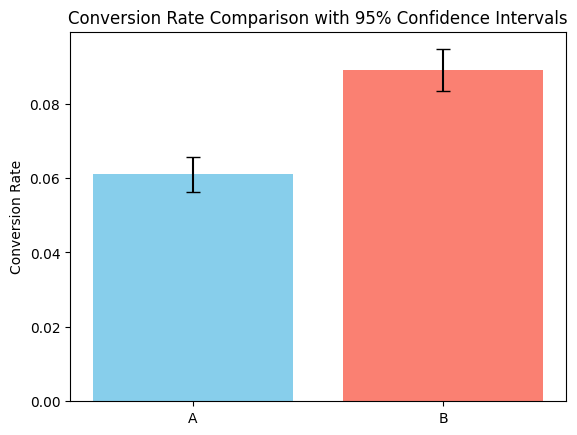

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Обчислення довірчих інтервалів
conf_int = [proportion_confint(count, n, method='normal') for count, n in zip(success, nobs)]

# Дані для графіка
groups = ['A', 'B']
means = conversion_rate.values
lower_bounds = [mean - ci[0] for mean, ci in zip(means, conf_int)]
upper_bounds = [ci[1] - mean for mean, ci in zip(means, conf_int)]

# Побудова графіка
plt.bar(groups, means, yerr=[lower_bounds, upper_bounds], capsize=5, color=['skyblue', 'salmon'])
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate Comparison with 95% Confidence Intervals')
plt.savefig("conversion_comparison.png", dpi=300)
plt.show()

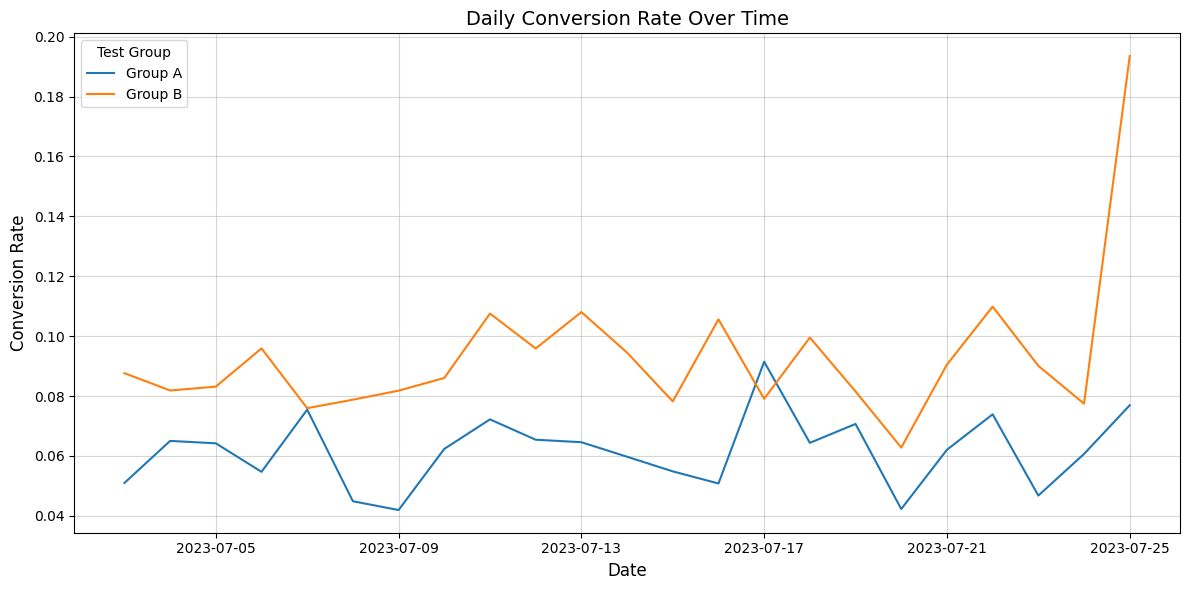

In [69]:
import matplotlib.pyplot as plt

# Додавання стовпця дати
ab['date'] = ab['timestamp'].dt.date

# Обчислення щоденної конверсії
daily_data = ab.groupby(['date', 'test_group']).agg(
    users=('user_id', 'count'),
    conversions=('conversion', 'sum')
).reset_index()

daily_data['conversion_rate'] = daily_data['conversions'] / daily_data['users']

# Побудова графіка
plt.figure(figsize=(12, 6))
for group in daily_data['test_group'].unique():
    group_data = daily_data[daily_data['test_group'] == group]
    plt.plot(group_data['date'], group_data['conversion_rate'], label=f'Group {group.upper()}')

plt.title('Daily Conversion Rate Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.legend(title='Test Group')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

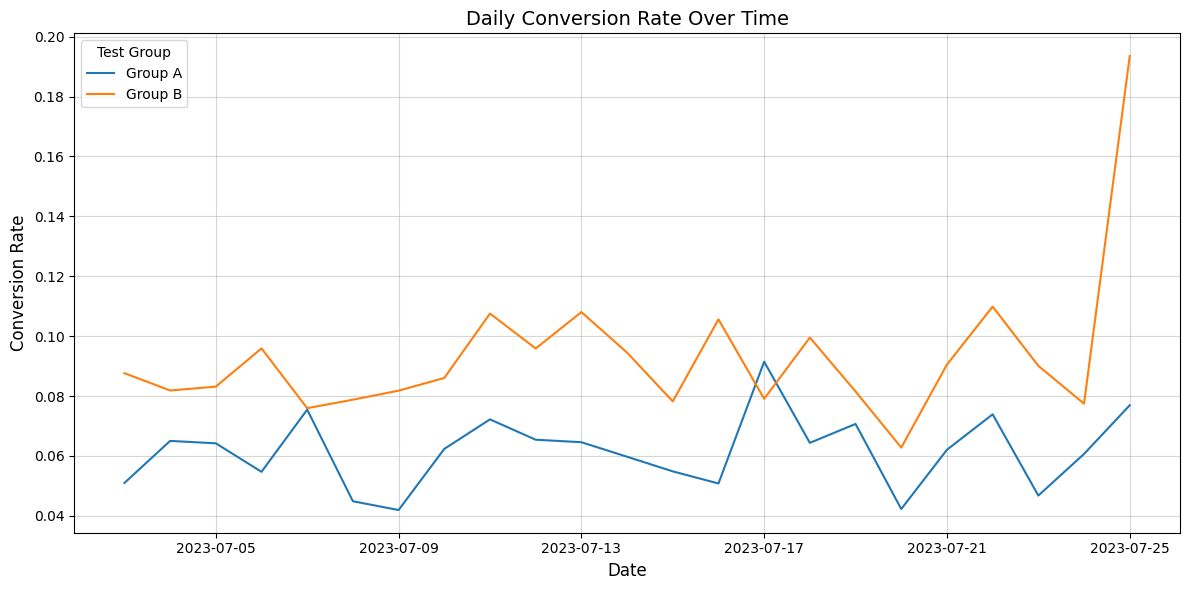

In [70]:
# Збереження графіка як зображення
plt.figure(figsize=(12, 6))
for group in daily_data['test_group'].unique():
    group_data = daily_data[daily_data['test_group'] == group]
    plt.plot(group_data['date'], group_data['conversion_rate'], label=f'Group {group.upper()}')

plt.title('Daily Conversion Rate Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.legend(title='Test Group')
plt.grid(alpha=0.5)
plt.tight_layout()

# Збереження в файл
plt.savefig("conversion_trend.png", dpi=300)
plt.show()

In [71]:

import math

# Параметри груп A і B
conversion_A = 0.061  # Конверсія групи A
conversion_B = 0.089  # Конверсія групи B
users_A = 10013       # Кількість користувачів у групі A
users_B = 9985        # Кількість користувачів у групі B

# Загальна конверсія
total_successes = (conversion_A * users_A) + (conversion_B * users_B)
total_users = users_A + users_B
p_hat = total_successes / total_users

# Розрахунок Z-статистики
numerator = conversion_A - conversion_B
denominator = math.sqrt(p_hat * (1 - p_hat) * ((1 / users_A) + (1 / users_B)))
z_statistic = numerator / denominator

# Виведення результату
print(f"Z-Statistic: {z_statistic}")

Z-Statistic: -7.517467397080393


In [72]:
from scipy import stats

alpha = 0.06

statistic, pvalue = stats.ttest_ind(ab[ab['test_group'] == 'a']['conversion'],
                                    ab[ab['test_group'] == 'b']['conversion'],
                                    alternative = 'less')
print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')
if pvalue < alpha:
  print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
  print('The difference is insignificant, Null Hypothesis cannot rejected.')

t-statistic: -7.53, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


In [73]:
# Завантажимо цей аналіз в pdf
!pip install fpdf2
from google.colab import files
from fpdf import FPDF

def write(pdf, text, size=11, style="", h=7):
    pdf.set_font("Arial", style, size)
    pdf.set_x(pdf.l_margin)
    pdf.multi_cell(0, h, text)

def section_title(pdf, text):
    pdf.set_x(pdf.l_margin)
    pdf.set_font("Arial", "B", 13)
    pdf.cell(0, 8, text, ln=True)
    pdf.ln(2)

pdf = FPDF()
pdf.set_margins(15, 15, 15)
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

# Заголовок
pdf.set_font("Arial", "B", 16)
pdf.cell(0, 10, "A/B Test - Subscription in App", ln=True, align="C")
pdf.ln(8)

# Мета тесту
section_title(pdf, "Test Goal")
write(pdf,
    "The goal of the test is to determine whether the '50% discount' framing "
    "increases user conversion to a subscription purchase."
)
pdf.ln(2)
write(pdf, "Group A: users are offered a subscription for $4.99.")
write(pdf, "Group B: users are offered a subscription for $4.99 with a 50% discount.")
pdf.ln(2)
write(pdf, "The key metric is conversion from install to payment.")
pdf.ln(6)

# Огляд даних
section_title(pdf, "Data Overview")

epw = pdf.epw
col_widths = [epw * 0.45, epw * 0.275, epw * 0.275]

data_rows = [
    ("Metric", "Group A", "Group B"),
    ("Users", "10,013", "9,985"),
    ("Conversions", "611", "889"),
    ("Conversion Rate", "6.10%", "8.90%"),
    ("Test Start", "2023-07-03", ""),
    ("Test End", "2023-07-25", ""),
    ("Test Duration", "21 days", ""),
]

for i, (label, val_a, val_b) in enumerate(data_rows):
    pdf.set_x(pdf.l_margin)
    if i == 0:
        pdf.set_font("Arial", "B", 11)
        pdf.set_fill_color(220, 220, 220)
        fill = True
    else:
        pdf.set_font("Arial", size=11)
        fill = i % 2 == 0
        pdf.set_fill_color(245, 245, 245) if fill else pdf.set_fill_color(255, 255, 255)
    pdf.cell(col_widths[0], 8, label, border=1, fill=fill)
    pdf.cell(col_widths[1], 8, val_a, border=1, align="C", fill=fill)
    pdf.cell(col_widths[2], 8, val_b, border=1, align="C", fill=fill, ln=True)

pdf.ln(6)

# Тестування
section_title(pdf, "Statistical Testing")
write(pdf,
    "To test the null hypothesis (H0: conversion rates in groups A and B are equal), "
    "a two-proportion z-test was used."
)
pdf.ln(2)
write(pdf, "Z-statistic: -7.519")
write(pdf, "p-value: 5.49e-14")
pdf.ln(2)
write(pdf,
    "Conclusion: p-value (5.49e-14) < 0.05, so the null hypothesis is rejected. "
    "The conversion rates in groups A and B are statistically different.",
    style="B"
)
pdf.ln(6)

# Візуалізація
section_title(pdf, "Visualization")
write(pdf,
    "The chart below compares conversion rates between groups with 95% confidence intervals. "
    "Group B shows a clearly higher conversion rate, and the non-overlapping confidence intervals "
    "confirm the result is statistically significant."
)
pdf.ln(3)
pdf.set_x(pdf.l_margin)
pdf.image("conversion_comparison.png", x=15, w=175)
pdf.ln(2)
write(pdf,
    "Figure 1. Conversion rate comparison between Group A and Group B "
    "with 95% confidence intervals.",
    style="I", size=10
)
pdf.ln(6)

write(pdf,
    "The chart below shows the daily conversion rate dynamics over the 21-day test period. "
    "Group B consistently outperformed Group A across most days."
)
pdf.ln(3)
pdf.set_x(pdf.l_margin)
pdf.image("conversion_trend.png", x=15, w=175)
pdf.ln(2)
write(pdf,
    "Figure 2. Daily conversion rate dynamics for both groups over the test period.",
    style="I", size=10
)
pdf.ln(10)

# Висновки
pdf.add_page()
section_title(pdf, "Conclusions")
write(pdf, "1. Group B (50% discount framing) showed a higher conversion rate compared to Group A.")
pdf.ln(2)
write(pdf,
    "2. Based on statistical testing, it can be concluded that the offer framing "
    "has a measurable impact on user purchasing behavior."
)
pdf.ln(6)

# Рекомендації
section_title(pdf, "Recommendations")
write(pdf,
    "1. Implement Variant B (50% discount framing) as the primary offer, as the difference "
    "is statistically significant (p < 0.05) and the effect is not due to random variation."
)
pdf.ln(2)
write(pdf,
    "2. Before full-scale rollout, evaluate long-term user behavior, "
    "including retention and subscription cancellation rates."
)

# Зберігаємо файл
pdf.output("AB_Test_Results.pdf")
files.download("AB_Test_Results.pdf")

/tmp/ipykernel_1795/4284624172.py:23: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 16)
/tmp/ipykernel_1795/4284624172.py:24: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "A/B Test - Subscription in App", ln=True, align="C")
/tmp/ipykernel_1795/4284624172.py:13: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 13)
/tmp/ipykernel_1795/4284624172.py:14: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, text, ln=True)
/tmp/ipykernel_1795/4284624172.py:7: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>